In [1]:
from spisea import synthetic, evolution, atmospheres, reddening
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

/home/wyz5rge/.local/lib/python3.6/site-packages/pysynphot/locations.py:345: UserWarning: Extinction files not found in /scratch/wyz5rge/models/cdbs/extinction
  warnings.warn('Extinction files not found in %s' % (extdir, ))


In [2]:
# ----------------------------
# User settings
# ----------------------------
log_age = 6.0
metallicity = 0.0
AKs = 0.0
distance = 4500

# Requested temperatures
# target_temps = [3000, 6000, 10000]   # K

# If you want a better set for H2O specifically, try:
target_temps = [3000, 3500, 4000, 4500]

# JWST NIRCam regime (roughly)
nircam_min_micron = 0.6
nircam_max_micron = 5.0

# Approximate filter centers (micron)
filter_centers = {
    "F115W": 1.15,
    "F162M": 1.62,
    "F182M": 1.82,
    "F200W": 2.00,
}

# ----------------------------
# Model choices
# ----------------------------
evo_model = evolution.Baraffe15()
atm_func = atmospheres.get_BTSettl_2015_atmosphere
red_law = reddening.RedLawCardelli(3.1)

In [3]:
iso = synthetic.IsochronePhot(
    log_age, AKs, distance,
    metallicity=metallicity,
    evo_model=evo_model,
    atm_func=atm_func,
    red_law=red_law,
)

points = iso.points

mass_grid = np.array(points["mass"], dtype=float)
teff_grid = np.array(points["Teff"], dtype=float)
logg_grid = np.array(points["logg"], dtype=float)

print(f"Isochrone has {len(mass_grid)} mass points.")
print("Min/Max mass on isochrone:", mass_grid.min(), mass_grid.max())
print("Min/Max Teff on isochrone:", teff_grid.min(), teff_grid.max())

Isochrone has 30 mass points.
Min/Max mass on isochrone: 0.01 1.4
Min/Max Teff on isochrone: 2343.696522948541 4658.000000000002


In [4]:
selected_stars = []

for target_teff in target_temps:
    idx = np.argmin(np.abs(teff_grid - target_teff))

    selected_stars.append({
        "target_teff": target_teff,
        "matched_teff": float(teff_grid[idx]),
        "mass": float(mass_grid[idx]),
        "logg": float(logg_grid[idx]),
        "idx": int(idx),
    })

print("Selected stars from 1 Myr isochrone:")
for s in selected_stars:
    print(
        f"Target Teff = {s['target_teff']:>5} K | "
        f"Matched Teff = {s['matched_teff']:8.2f} K | "
        f"Mass = {s['mass']:.4f} Msun | "
        f"logg = {s['logg']:.3f}"
    )

Selected stars from 1 Myr isochrone:
Target Teff =  3000 K | Matched Teff =  3012.82 K | Mass = 0.1300 Msun | logg = 3.385
Target Teff =  3500 K | Matched Teff =  3426.20 K | Mass = 0.3000 Msun | logg = 3.496
Target Teff =  4000 K | Matched Teff =  3954.46 K | Mass = 0.6000 Msun | logg = 3.629
Target Teff =  4500 K | Matched Teff =  4529.00 K | Mass = 1.2000 Msun | logg = 3.687


In [5]:
sed_data = []

for s in selected_stars:
    sed = atm_func(
        temperature=s["matched_teff"],
        gravity=s["logg"],
        metallicity=metallicity
    )

    wavelength_A = np.array(sed.wave, dtype=float)
    flux = np.array(sed.flux, dtype=float)

    wavelength_micron = wavelength_A * 1e-4   # 1 Å = 1e-4 micron

    nircam_mask = (
        (wavelength_micron >= nircam_min_micron) &
        (wavelength_micron <= nircam_max_micron)
    )

    sed_data.append({
        "target_teff": s["target_teff"],
        "matched_teff": s["matched_teff"],
        "mass": s["mass"],
        "logg": s["logg"],
        "wavelength_A": wavelength_A,
        "wavelength_micron": wavelength_micron,
        "flux": flux,
        "nircam_mask": nircam_mask,
    })

print(f"Generated {len(sed_data)} SEDs.")

Generated 4 SEDs.


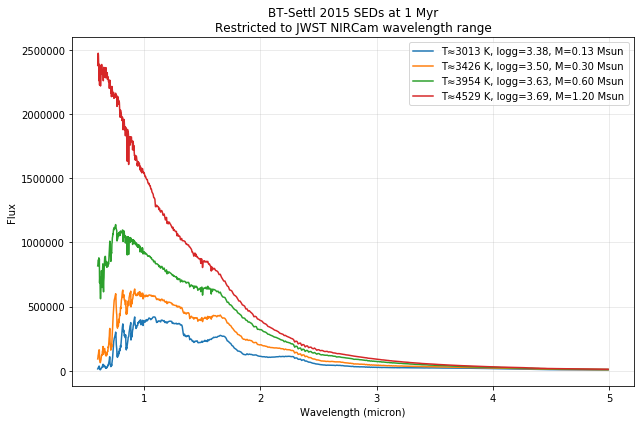

In [6]:
plt.figure(figsize=(9, 6))

for d in sed_data:
    w = d["wavelength_micron"][d["nircam_mask"]]
    f = d["flux"][d["nircam_mask"]]

    plt.plot(
        w, f,
        label=f"T≈{d['matched_teff']:.0f} K, logg={d['logg']:.2f}, M={d['mass']:.2f} Msun"
    )

plt.xlabel("Wavelength (micron)")
plt.ylabel("Flux")
plt.title("BT-Settl 2015 SEDs at 1 Myr\nRestricted to JWST NIRCam wavelength range")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

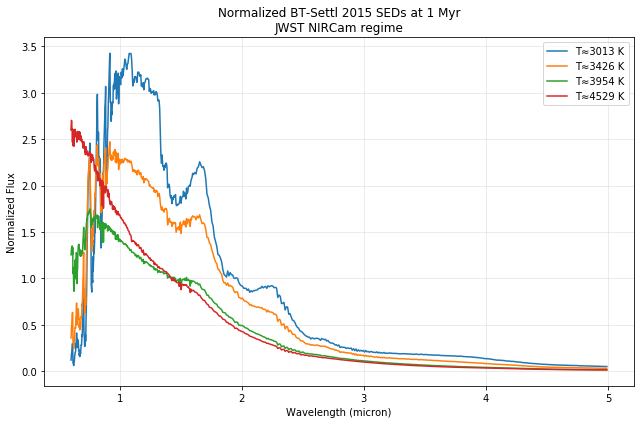

In [7]:
plt.figure(figsize=(9, 6))

for d in sed_data:
    w = d["wavelength_micron"][d["nircam_mask"]]
    f = d["flux"][d["nircam_mask"]]

    f_norm = f / np.median(f)

    plt.plot(
        w, f_norm,
        label=f"T≈{d['matched_teff']:.0f} K"
    )

plt.xlabel("Wavelength (micron)")
plt.ylabel("Normalized Flux")
plt.title("Normalized BT-Settl 2015 SEDs at 1 Myr\nJWST NIRCam regime")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
filter_bands = {
    "F115W": {"center": 1.15,  "blue": None,   "red": None},
    "F162M": {"center": 1.627, "blue": 1.542,  "red": 1.713},
    "F182M": {"center": 1.845, "blue": 1.722,  "red": 1.968},
    "F200W": {"center": 1.988, "blue": 1.755,  "red": 2.227},
}

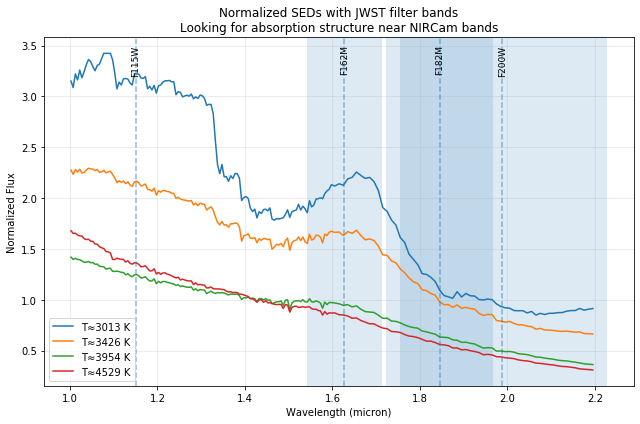

In [9]:
plt.figure(figsize=(9, 6))

for d in sed_data:
    w = d["wavelength_micron"][d["nircam_mask"]]
    f = d["flux"][d["nircam_mask"]]
    f_norm = f / np.median(f)

    zoom_mask = (w >= 1.0) & (w <= 2.2)

    plt.plot(
        w[zoom_mask], f_norm[zoom_mask],
        label=f"T≈{d['matched_teff']:.0f} K"
    )

ax = plt.gca()
ymin, ymax = ax.get_ylim()

for filt, info in filter_bands.items():
    blue = info["blue"]
    red = info["red"]
    center = info["center"]

    if blue is not None and red is not None:
        plt.axvspan(blue, red, alpha=0.15)
        plt.axvline(center, linestyle="--", alpha=0.5)
        plt.text(center, ymax * 0.98, filt, rotation=90, va="top", ha="center", fontsize=9)
    else:
        # fallback if only center is known
        plt.axvline(center, linestyle="--", alpha=0.5)
        plt.text(center, ymax * 0.98, filt, rotation=90, va="top", ha="center", fontsize=9)

plt.xlabel("Wavelength (micron)")
plt.ylabel("Normalized Flux")
plt.title("Normalized SEDs with JWST filter bands\nLooking for absorption structure near NIRCam bands")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

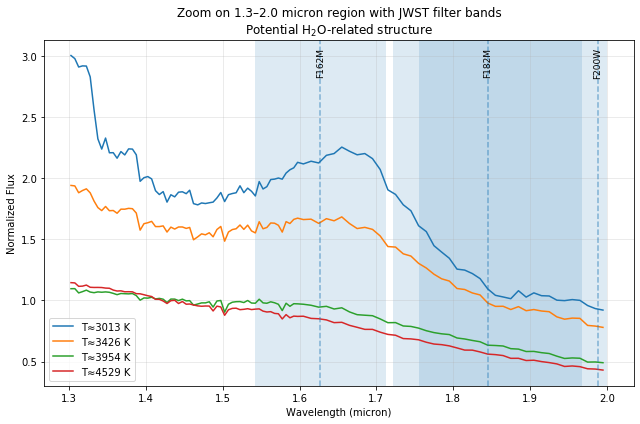

In [10]:
plt.figure(figsize=(9, 6))

for d in sed_data:
    w = d["wavelength_micron"][d["nircam_mask"]]
    f = d["flux"][d["nircam_mask"]]
    f_norm = f / np.median(f)

    zoom_mask = (w >= 1.3) & (w <= 2.0)

    plt.plot(
        w[zoom_mask], f_norm[zoom_mask],
        label=f"T≈{d['matched_teff']:.0f} K"
    )

ax = plt.gca()
ymin, ymax = ax.get_ylim()

for filt, info in filter_bands.items():
    blue = info["blue"]
    red = info["red"]
    center = info["center"]

    if red < 1.3 or blue > 2.0 if (blue is not None and red is not None) else False:
        continue

    if blue is not None and red is not None:
        # clip shading to visible range
        left = max(blue, 1.3)
        right = min(red, 2.0)
        if left < right:
            plt.axvspan(left, right, alpha=0.15)
        if 1.3 <= center <= 2.0:
            plt.axvline(center, linestyle="--", alpha=0.5)
            plt.text(center, ymax * 0.98, filt, rotation=90, va="top", ha="center", fontsize=9)
    else:
        if 1.3 <= center <= 2.0:
            plt.axvline(center, linestyle="--", alpha=0.5)
            plt.text(center, ymax * 0.98, filt, rotation=90, va="top", ha="center", fontsize=9)

plt.xlabel("Wavelength (micron)")
plt.ylabel("Normalized Flux")
plt.title("Zoom on 1.3–2.0 micron region with JWST filter bands\nPotential H$_2$O-related structure")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()